Linear regression is a supervised machine learning algorithm used to predict a continuous value (like house price)

It finds a line (or plane, in multiple dimensions) that best fits your data:

𝑃𝑟𝑖𝑐𝑒= 𝑚1 × 𝐴𝑟𝑒𝑎 + 𝑚2 × 𝐵𝑒𝑑𝑟𝑜𝑜𝑚𝑠 +⋯+ 𝑏 

Here:

Each column (Area, Bedrooms, etc.) = feature (X)

Price = target (y) (the value you want to predict)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

In [26]:
import warnings

# Suppress all UserWarnings from scikit-learn
warnings.filterwarnings("ignore", category=UserWarning)


In [2]:
data = pd.read_csv(r"E:\MachineLearning\House Price Prediction Dataset.csv")

In [6]:
data.drop("Id",axis = 1,inplace = True)

In [7]:
data.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [8]:
data.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Area       2000 non-null   int64 
 1   Bedrooms   2000 non-null   int64 
 2   Bathrooms  2000 non-null   int64 
 3   Floors     2000 non-null   int64 
 4   YearBuilt  2000 non-null   int64 
 5   Location   2000 non-null   object
 6   Condition  2000 non-null   object
 7   Garage     2000 non-null   object
 8   Price      2000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 140.8+ KB


In [13]:
# data cleaning and Encoding 
# Ml models work with numerical number only
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data["Location"] = le.fit_transform(data["Location"])
data["Condition"] = le.fit_transform(data["Condition"])
data["Garage"] = le.fit_transform(data["Garage"])


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       2000 non-null   int64
 1   Bedrooms   2000 non-null   int64
 2   Bathrooms  2000 non-null   int64
 3   Floors     2000 non-null   int64
 4   YearBuilt  2000 non-null   int64
 5   Location   2000 non-null   int32
 6   Condition  2000 non-null   int32
 7   Garage     2000 non-null   int32
 8   Price      2000 non-null   int64
dtypes: int32(3), int64(6)
memory usage: 117.3 KB


In [17]:
# Prepare the Data for Training
# Separate the featues (X) and target (y)
X = data[["Area","Bedrooms","Bathrooms","Floors","YearBuilt","Location","Condition","Garage"]]
y = data["Price"]

In [18]:
# Split Data into Training and Testing sets
# when use part of the data to train and rest to test
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [19]:
# Train the Linear Regression Model 
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [22]:
# Test the Model 
# Now: let's predict and check how well our model perform
y_pred = model.predict(X_test)

In [42]:
print("R2 Score: ",r2_score(y_test,y_pred))
print("MSE ",mean_squared_error(y_test,y_pred))

R2 Score:  -0.011961539273188215
MSE  78729422262.6482


In [40]:
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
print(r2)

-0.011961539273188215


In [41]:
rmse = np.sqrt(mse)
print(rmse)

280587.6374016649


In [27]:
# Predict a new house price 
new_house = [[2500,3,2,2,2000,1,2,1]]
predicted_price = model.predict(new_house)
print("Predicted House Price:",predicted_price[0])

Predicted House Price: 547869.0063479117


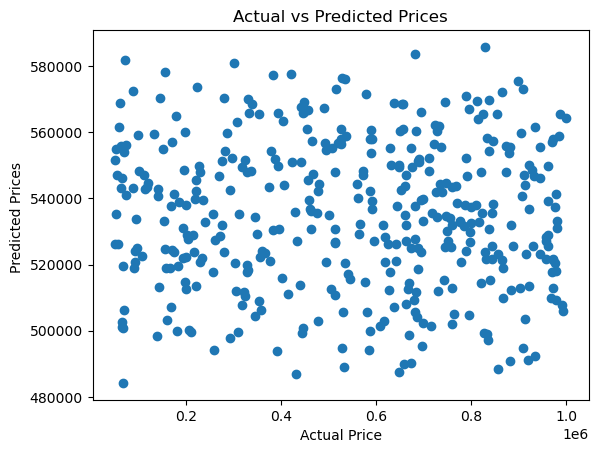

In [43]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Prices ")
plt.title("Actual vs Predicted Prices")
plt.show()

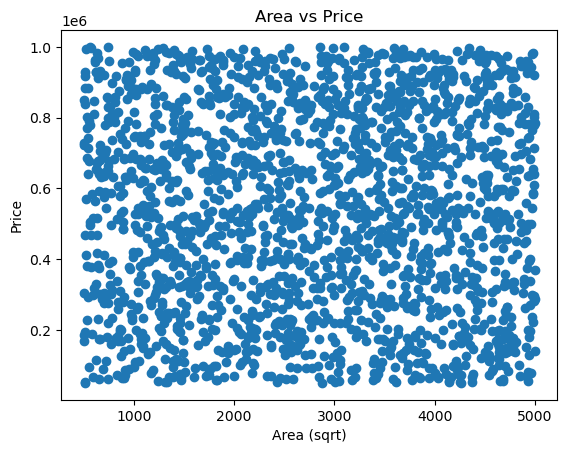

In [28]:
# visualize the Relationship
plt.scatter(data["Area"],data["Price"])
plt.xlabel("Area (sqrt)")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [29]:
import seaborn as sns

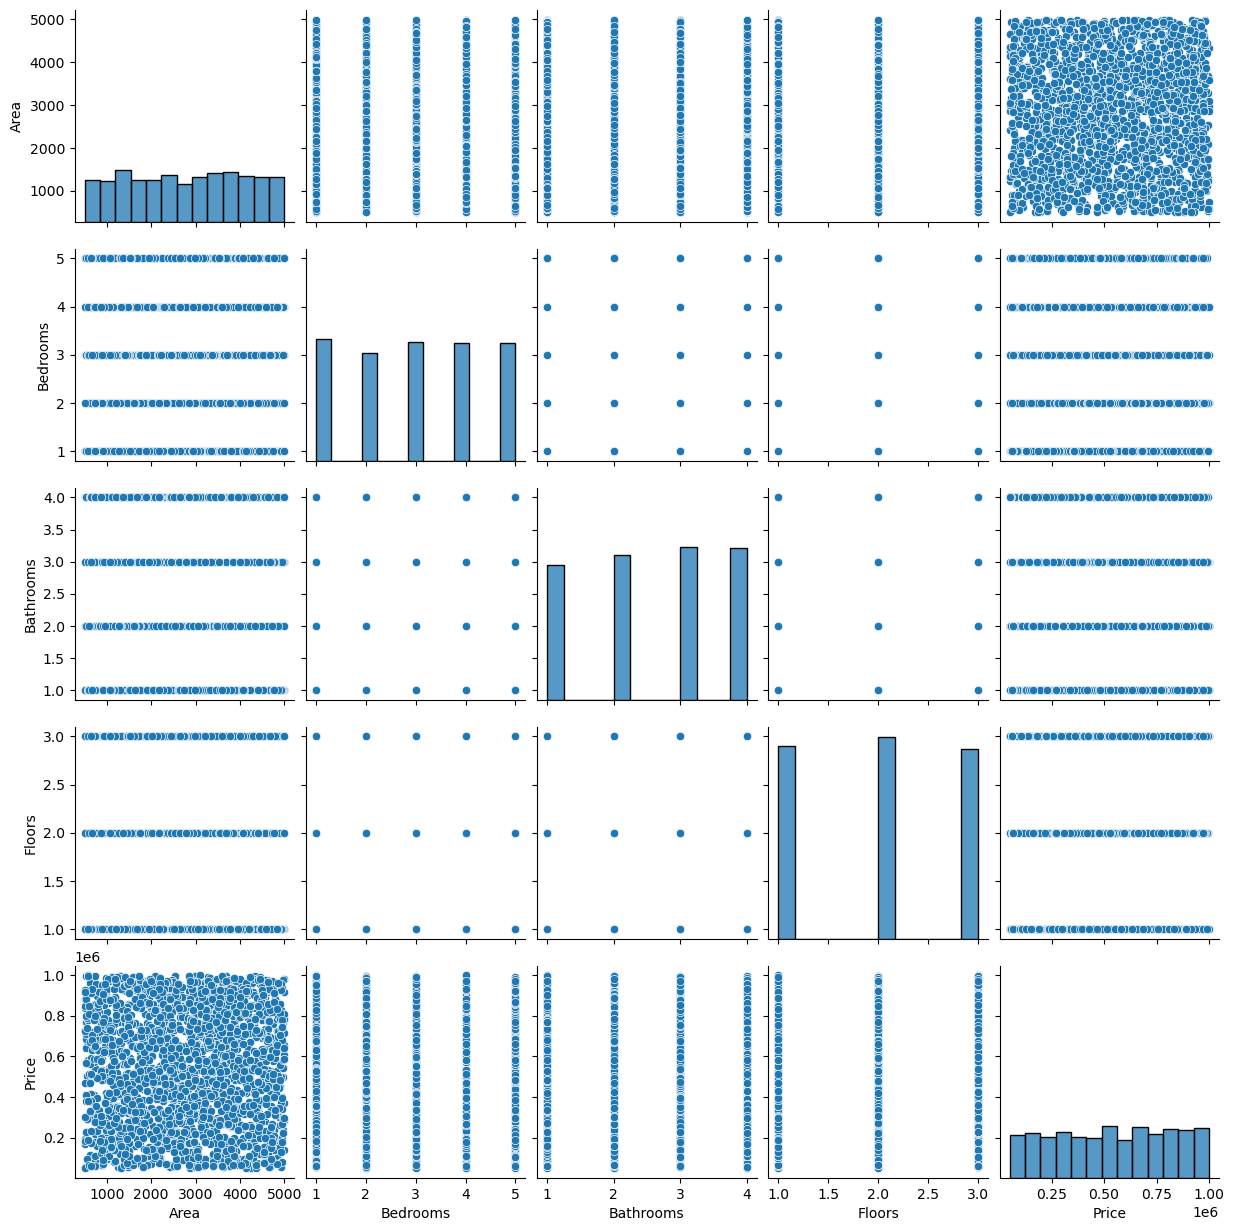

In [30]:
sns.pairplot(data[["Area","Bedrooms","Bathrooms","Floors","Price"]])
plt.show()

In [31]:
print(data.corr())

               Area  Bedrooms  Bathrooms    Floors  YearBuilt  Location  \
Area       1.000000  0.047523   0.021881  0.017749  -0.011609 -0.003910   
Bedrooms   0.047523  1.000000  -0.011990  0.010435  -0.014125  0.016958   
Bathrooms  0.021881 -0.011990   1.000000  0.029089  -0.000839 -0.016471   
Floors     0.017749  0.010435   0.029089  1.000000  -0.006474  0.006430   
YearBuilt -0.011609 -0.014125  -0.000839 -0.006474   1.000000 -0.040727   
Location  -0.003910  0.016958  -0.016471  0.006430  -0.040727  1.000000   
Condition  0.002030  0.006743   0.020183  0.021006   0.025780  0.028387   
Garage    -0.003441 -0.041713   0.004057 -0.004635  -0.011703  0.019827   
Price      0.001542 -0.003471  -0.015737  0.055890   0.004845 -0.012289   

           Condition    Garage     Price  
Area        0.002030 -0.003441  0.001542  
Bedrooms    0.006743 -0.041713 -0.003471  
Bathrooms   0.020183  0.004057 -0.015737  
Floors      0.021006 -0.004635  0.055890  
YearBuilt   0.025780 -0.011703  0.

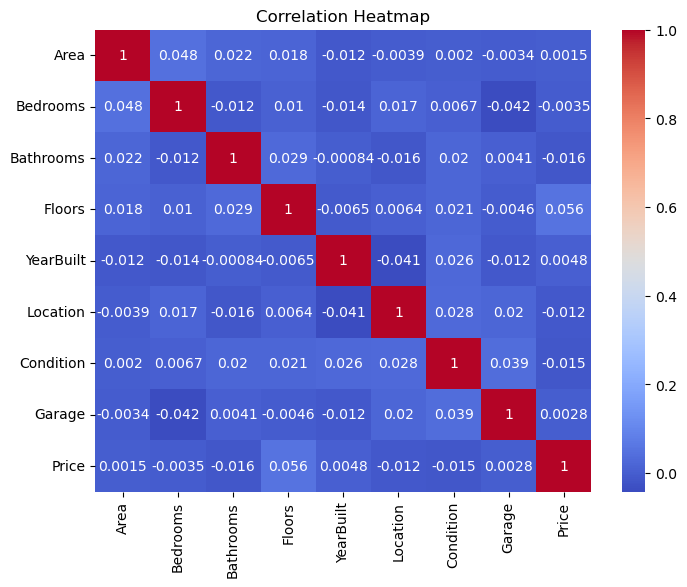

In [32]:
plt.figure(figsize = (8,6))
sns.heatmap(data.corr(),annot = True,cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()